In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print(np.__version__)
print(pd.__version__)
print(sns.__version__)

1.26.4
2.3.3
0.13.2


In [ ]:
#Supervised Machine learning is of two types
#---->Regression:Output is continuous
#---->Classification:Output is catagorical

In [ ]:
#Steps of ml:
#1.--Data Reading
#2.--Data Cleaning
#3.--Data Analysing
#4.--Encoding(if needed):helps to convert text data to numeric
#5.--IP/OP creation
#6.--train,test,split(split the data for training and testing)
#7.--Ml Model
#8.--Prediction
#9.--Accuracy

## DATA READING

In [40]:
adv=pd.read_csv(r"C:\Users\ASUS\Desktop\advertising.csv")
adv

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


## DATA CLEANING

In [4]:
adv.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
adv.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

## DATA ANALYSIS

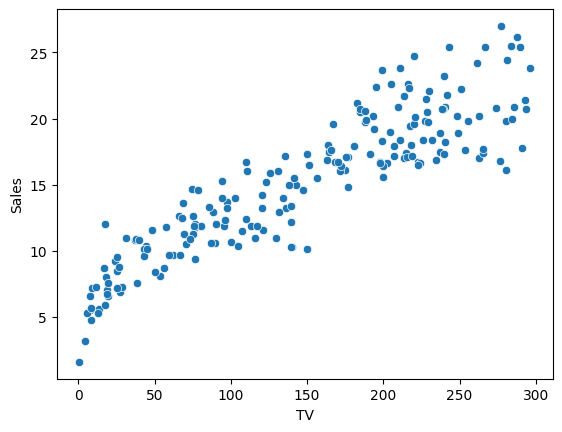

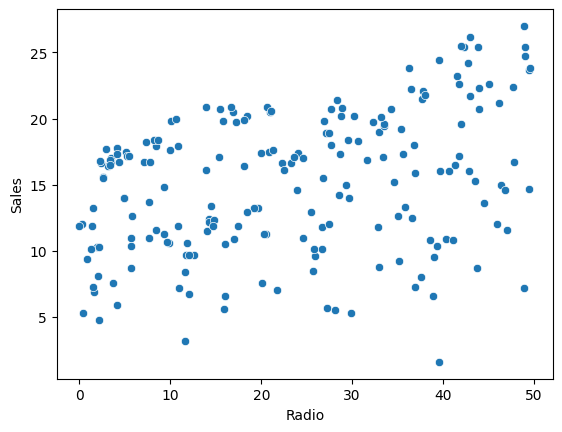

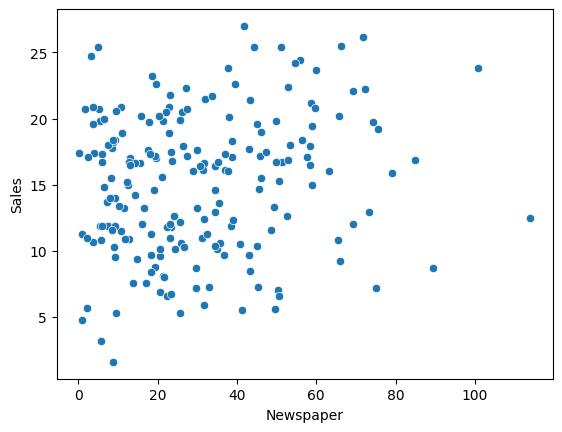

In [6]:
sns.scatterplot(x=adv.TV,y=adv.Sales)
plt.show()
sns.scatterplot(x=adv.Radio,y=adv.Sales)
plt.show()
sns.scatterplot(x=adv.Newspaper,y=adv.Sales)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

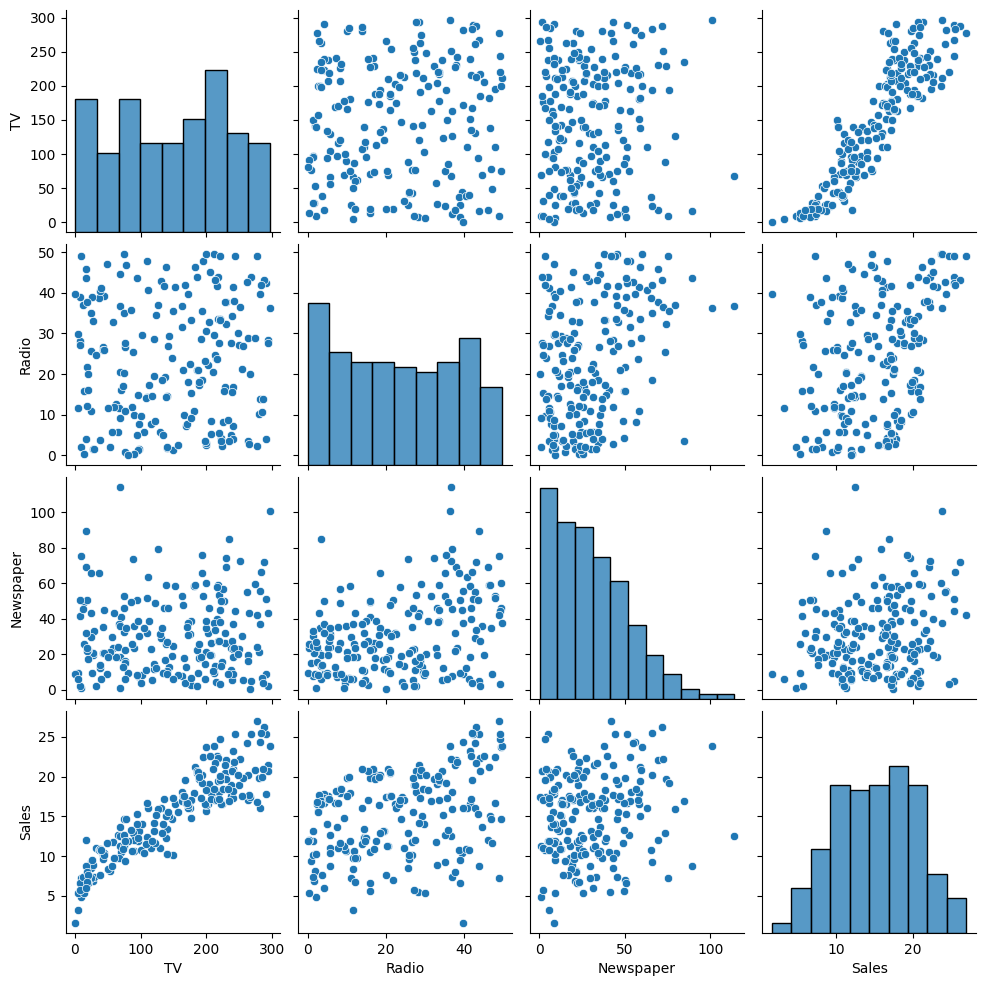

In [52]:
#pair plot
sns.pairplot(adv)
plt.show

## IP/OP CREATION

In [42]:
ip=adv.drop('Sales',axis=1)#if adv=adv.drop() then it gets deeleted
op=adv.Sales

In [43]:
print('INPUT--------\n',ip.head())
print('OUTPUT--------\n',op.head())

INPUT--------
       TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
OUTPUT--------
 0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


## Train,Test,Split():Split data into train and test

In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(ip,op,test_size=0.2)

In [45]:
print(x_train.head(),'-----',y_train.head())
print(x_train.head(),'-----',y_test.head())

       TV  Radio  Newspaper
83   68.4   44.5       35.6
47  239.9   41.5       18.5
1    44.5   39.3       45.1
75   16.9   43.7       89.4
12   23.8   35.1       65.9 ----- 83    13.6
47    23.2
1     10.4
75     8.7
12     9.2
Name: Sales, dtype: float64
       TV  Radio  Newspaper
83   68.4   44.5       35.6
47  239.9   41.5       18.5
1    44.5   39.3       45.1
75   16.9   43.7       89.4
12   23.8   35.1       65.9 ----- 104    20.7
38     10.1
191    11.9
58     23.8
64     16.0
Name: Sales, dtype: float64


In [46]:
print(x_train.shape)
print(x_test.shape)

(160, 3)
(40, 3)


## Standard Scalar(z=(x-mean)/standard deviation)

In [47]:
adv.describe(include='all')

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [48]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [49]:
x_train

array([[-0.88721942,  1.43162333,  0.27398331],
       [ 1.08730558,  1.22855619, -0.53292555],
       [-1.16238646,  1.07964029,  0.722266  ],
       [-1.48015258,  1.3774721 ,  2.812679  ],
       [-1.40071105,  0.7953463 ,  1.70376917],
       [-1.02768126, -1.19471167, -0.00442384],
       [-0.81468585,  1.76329966,  0.75057859],
       [ 0.29749558,  1.10671591,  0.37307738],
       [ 0.68549262,  1.47223676, -0.48101913],
       [ 1.33368946,  1.30978305,  1.17526746],
       [ 1.08960823, -1.0864092 , -0.99536454],
       [-0.06862626, -1.43839224, -0.15070556],
       [ 1.18516833,  0.46366997, -0.44798777],
       [ 1.10802946,  0.99164453, -0.31114358],
       [-1.31205891,  0.08461131, -1.30208428],
       [ 1.26576119,  0.24029612, -1.14636503],
       [ 1.63648833,  1.33008976,  1.98217632],
       [ 0.26410711, -1.09994701, -0.80189517],
       [ 0.55539272,  0.81565301,  2.1614894 ],
       [ 0.81674384,  1.242094  ,  0.46273392],
       [ 0.97447558,  0.97810672,  1.859

## Linear Regression:used to see the linear relatioship between ip and op

In [50]:
from sklearn.linear_model import LinearRegression
li=LinearRegression()

In [51]:
#input
x=adv[['TV','Radio','Newspaper']]
#output
y=adv[['Sales']]

In [52]:
model=li.fit(x,y)
#slope
slope=model.coef_
print('slope-->',slope)
#intercept
print('intercept',li.intercept_)

slope--> [[0.05444578 0.10700123 0.00033566]]
intercept [4.62512408]


In [53]:
tv=230.1
radio=37.8
news=69.3
#slope
s1=0.05444578
s2=0.10700123
s3=0.00033566
i=4.62512408

In [54]:
output=i+(s1*tv)+(s2*radio)+(s3*news)
print('output------->',output)

output-------> 21.221005790000003


In [55]:
li.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[4.77,1.51,0.13]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[15.01,12.49, 9.93]"


In [56]:
pred=li.predict(x_test)
print(pred)
print("--------------")
print(y_test)

[21.06355634  8.87404194  9.03239663 21.16079873 15.68935866  9.80763458
 11.22489602 15.80765366  8.09309351 22.94051651 11.86674832 12.00448799
 12.10586432 18.18695339  9.57125733 10.85333779 18.18011843 11.71202362
 20.11697603 21.71655927  8.24263844 23.92684868  8.12935769  8.09264197
 17.06677594 14.93826153 18.9301764  18.01540056 25.04202602 13.67251572
 13.30095519 21.84121961 16.5889519  10.02451604 11.78962008 15.57509273
 17.13359444 10.81847862 16.91986082 21.46779455]
--------------
104    20.7
38     10.1
191    11.9
58     23.8
64     16.0
148    10.9
79     11.0
50     16.4
126     6.6
137    20.8
73     11.0
145    10.3
31     11.9
165    16.9
140    10.9
144    12.3
21     17.5
115    12.6
133    19.6
150    16.1
127    11.9
30     21.4
117     9.4
158     7.3
122    16.6
26     15.0
168    17.1
113    20.9
175    27.0
156    15.3
159    12.9
188    20.9
162    19.9
13     13.7
16     12.5
171    17.5
85     20.2
86     12.0
3      16.5
128    24.7
Name: Sales, dtyp

In [57]:
from sklearn.metrics import r2_score,mean_squared_error
print('accuracy----->',r2_score(y_test,pred))
print('Mean_squared_error---->',mean_squared_error(y_test,pred))

accuracy-----> 0.8270666215474187
Mean_squared_error----> 3.978332371301632


In [58]:
df=pd.DataFrame({'original':y_test,'Machine_value':pred})
df

,original,Machine_value
104,20.7,21.063556
38,10.1,8.874042
191,11.9,9.032397
58,23.8,21.160799
64,16.0,15.689359
148,10.9,9.807635
79,11.0,11.224896
50,16.4,15.807654
126,6.6,8.093094
137,20.8,22.940517


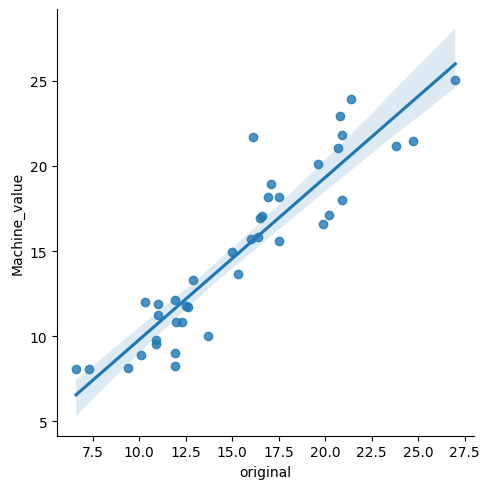

In [59]:
#lm plot()
sns.lmplot(x='original',y='Machine_value',data=df)
plt.show()

In [60]:
import joblib
model=joblib.dump(li,'ADV_')

In [61]:
model=joblib.load(r"C:\Users\ASUS\Desktop\CTTC PROGRAM\ADV_")

In [ ]:
#y=c+m1.x1+m2.x2+m3.x3+m4.x1.x2+m5.x2.x3+m6.(x2**2).x1+m7.(x2**2).x1
#there is no polynomial regression instead there is polynomial features

In [62]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)

In [63]:
x_train_scaled=poly.fit_transform(x_train)
x_test_scaled=poly.fit_transform(x_test)

In [64]:
li=LinearRegression()
li.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 0. , 4.28, 0.96,...,-0.22,-0.06,-0.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.42
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,19
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[65.16,39.41,29.41,..., 3.94, 2.97, 0. ]"


In [65]:
pred1=li.predict(x_test_scaled)
pred1

array([20.58623355,  7.76245791, 10.20746808, 24.05254783, 16.70203345,
        7.85404099, 12.46835585, 15.81209318,  5.31321819, 22.27145338,
       12.90274654, 13.65901318, 12.80382104, 17.50758503, 10.03837369,
       11.58762117, 17.46178467, 11.2616161 , 19.96420292, 20.18923116,
        9.69578076, 22.63964641,  9.27718157,  5.37469268, 16.74396612,
       15.35565238, 18.70697035, 17.75678665, 27.68129232, 13.89691598,
       13.97323107, 19.17995788, 16.7782192 , 11.67358917, 10.63370402,
       15.92377511, 17.26525216, 10.50873553, 17.42011947, 24.9433051 ])

In [34]:
from sklearn.utils import all_estimators

# Get all machine learning models (estimators)
estimators = all_estimators(type_filter=None)

print(f"Total models available: {len(estimators)}\n")
for name, class_type in estimators:
    print(f"{name:<30} -> {class_type.__module__}.{class_type.__name__}")


Total models available: 208

ARDRegression                  -> sklearn.linear_model._bayes.ARDRegression
AdaBoostClassifier             -> sklearn.ensemble._weight_boosting.AdaBoostClassifier
AdaBoostRegressor              -> sklearn.ensemble._weight_boosting.AdaBoostRegressor
AdditiveChi2Sampler            -> sklearn.kernel_approximation.AdditiveChi2Sampler
AffinityPropagation            -> sklearn.cluster._affinity_propagation.AffinityPropagation
AgglomerativeClustering        -> sklearn.cluster._agglomerative.AgglomerativeClustering
BaggingClassifier              -> sklearn.ensemble._bagging.BaggingClassifier
BaggingRegressor               -> sklearn.ensemble._bagging.BaggingRegressor
BayesianGaussianMixture        -> sklearn.mixture._bayesian_mixture.BayesianGaussianMixture
BayesianRidge                  -> sklearn.linear_model._bayes.BayesianRidge
BernoulliNB                    -> sklearn.naive_bayes.BernoulliNB
BernoulliRBM                   -> sklearn.neural_network._rbm.Bernoul

In [66]:
from sklearn.metrics import r2_score ,mean_squared_error
print('Accuracy---->',r2_score(y_test,pred1))
print('Mean_squared_error--->',mean_squared_error(y_test,pred1))

Accuracy----> 0.8681623618548063
Mean_squared_error---> 3.0329248655301795


## KNR(K-Neighbors Regression)
it is a machinelearning tool that predicts a number,by looking at the most similar data points it already knows about.It works like "ask your neighbour" methord in real life.

In [ ]:
#formula-root of((x2-x1)**2+(y2-y1)**2)

In [67]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)

In [68]:
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [69]:
pred2=knn.predict(x_test)
pred2

array([20.54,  9.1 , 11.44, 22.92, 15.32,  8.3 , 11.28, 16.92,  9.44,
       22.28, 10.92, 14.42, 10.9 , 18.1 ,  9.7 , 10.9 , 17.16, 10.26,
       19.2 , 19.9 , 10.58, 19.66,  9.7 ,  9.2 , 17.18, 15.06, 18.9 ,
       18.26, 23.48, 14.  , 13.68, 18.36, 17.86, 11.88, 11.34, 16.58,
       18.2 , 11.36, 17.22, 22.3 ])

In [70]:
from sklearn.metrics import r2_score ,mean_squared_error
print('Accuracy---->',r2_score(y_test,pred2))
print('Mean_squared_error--->',mean_squared_error(y_test,pred2))

Accuracy----> 0.8659369702238644
Mean_squared_error---> 3.084119999999998


## SVR(support vector regression)
svr is a machine learning tool used to predict number based on past data

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [71]:
y_train=sc.fit_transform(y_train)##cannot use 1d containter y contains sales only

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [74]:
y_train=sc.fit_transform(y_train.values.reshape(-1,1)).ravel()used to convert into 2D 

In [75]:
y_train

array([-0.26737145,  1.51742885, -0.86230489, -1.17836327, -1.08540492,
       -1.17836327, -0.06286308,  0.17882862,  1.40587883,  1.70334555,
        0.58784536, -0.88089655,  0.95967876,  1.25714547, -0.75075487,
        0.88531208,  2.07517894,  0.30897031,  0.77376206,  1.40587883,
        1.31292048, -1.56878834,  1.08982044, -1.43864665, -2.49837183,
       -1.23413828, -1.30850496, -0.52765483, -1.55019667,  1.33151215,
       -0.86230489, -1.51301333, -1.01103824, -0.82512155, -0.19300477,
       -0.69497986, -0.58342984, -1.73611337,  0.51347868, -0.60202151,
       -0.19300477, -0.34173813,  0.30897031, -0.19300477, -1.28991329,
       -1.1597716 ,  1.6103872 , -0.08145475,  0.6250287 , -0.78793821,
        0.32756198, -1.77329671,  0.30897031, -0.30455479,  1.03404543,
        0.92249542,  1.92644559,  0.42052033, -1.49442166, -0.08145475,
       -0.63920485,  0.27178697,  0.08587027, -1.02962991,  0.10446194,
        0.40192866,  0.94108709, -0.00708807,  1.74052889, -1.21

In [77]:
from sklearn.svm import SVR
svr=SVR()
svr.fit(x_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [80]:
pred4=svr.predict(x_test)
pred4

array([ 1.01202509, -1.28481832, -1.07009522,  1.49184024,  0.2739861 ,
       -1.1389889 , -0.54239447,  0.22394136, -1.21859514,  1.09334604,
       -0.39621551, -0.25356409, -0.50032513,  0.39077389, -1.05332349,
       -0.75532947,  0.50348982, -0.69395044,  0.87571054,  0.84408401,
       -0.94861351,  1.10880891, -1.04149892, -1.30433562,  0.35559317,
        0.01232144,  0.57021563,  0.47485506,  1.89021078, -0.21965043,
       -0.25445328,  0.75693392,  0.32979619, -0.78199467, -0.62971366,
        0.1061848 ,  0.37812914, -0.84889306,  0.45991744,  1.28916417])

In [90]:
from sklearn.metrics import r2_score ,mean_squared_error
print('Accuracy---->',r2_score(y_test,pred4))
print('Mean_squared_error--->',mean_squared_error(y_test,pred4))

Accuracy----> -10.160115813299305
Mean_squared_error---> 256.7384642849505


In [88]:
y_pred=sc.inverse_transform(pred4.reshape(-1,1))
y_pred

array([[20.48155801],
       [ 8.1274046 ],
       [ 9.28234709],
       [23.06236516],
       [16.51182858],
       [ 8.91178504],
       [12.12071913],
       [16.24265026],
       [ 8.48360272],
       [20.91896331],
       [12.90697963],
       [13.67426636],
       [12.34699967],
       [17.14000123],
       [ 9.37255809],
       [10.97539436],
       [17.74627241],
       [11.30553696],
       [19.74835569],
       [19.57824443],
       [ 9.9357672 ],
       [21.00213426],
       [ 9.43615954],
       [ 8.02242585],
       [16.95077282],
       [15.10439898],
       [18.10517402],
       [17.5922531 ],
       [25.20510191],
       [13.85667958],
       [13.66948365],
       [19.10948561],
       [16.81201724],
       [10.8319688 ],
       [11.65105073],
       [15.60926683],
       [17.07198827],
       [10.47213889],
       [17.51190733],
       [21.97222068]])

In [89]:
from sklearn.metrics import r2_score ,mean_squared_error
print('Accuracy---->',r2_score(y_test,y_pred))
print('Mean_squared_error--->',mean_squared_error(y_test,y_pred))

Accuracy----> 0.8674362294782024
Mean_squared_error---> 3.049629540853953
